In [2]:
import Pkg;
Pkg.activate(@__DIR__);
Pkg.instantiate()

  Activating environment at `~/Git/cartpole/Controller/TinyMPC/Project.toml`


In [801]:
using LinearAlgebra
using ForwardDiff
using Plots
using Random
using Printf
using MeshCat
using TrajOptPlots
using RobotZoo:Cartpole
using StaticArrays
using GeometryTypes
# using ColorTypes

In [802]:
vis = Visualizer()
model = Cartpole()
TrajOptPlots.set_mesh!(vis, model)

┌ Info: MeshCat server started. You can open the visualizer by visiting the following URL in your browser:
│ http://127.0.0.1:8705
└ @ MeshCat /home/sam/.julia/packages/MeshCat/GlCMx/src/visualizer.jl:73


MeshCat Visualizer with path /meshcat/robot/cart/pole at http://127.0.0.1:8705

In [803]:
# Cartpole params
m1 = 1.0
m2 = 0.2
ℓ = 0.5
J = 0.006 # mass moment of inertia of pendulum
# b = 0.1
friction = 0

g = 9.81

h = 1/100

0.01

In [804]:
# x = [x, v, θ, θdot]

function cartpole_dynamics(x,u)
  r = x[1] # cart position
  ṙ = x[2] # pole angle
  θ = x[3] # change in cart position
  θ̇ = x[4] # change in pole angle

  F = u[1]

  a = [(m1+m2) m2*ℓ*cos(θ); m2*ℓ*cos(θ) J+m2*ℓ^2]
  b = [F - friction*ṙ + m2*ℓ*sin(θ)*θ̇ ^2; -m2*g*ℓ*sin(θ)]

  ẍ = a^(-1)*b

  return [ṙ; ẍ[1]; θ̇ ; ẍ[2]]
end
function cartpole_rk4(x,u)
  #RK4 integration with zero-order hold on u
  f1 = cartpole_dynamics(x, u)
  f2 = cartpole_dynamics(x + 0.5*h*f1, u)
  f3 = cartpole_dynamics(x + 0.5*h*f2, u)
  f4 = cartpole_dynamics(x + h*f3, u)
  xn = x + (h/6.0)*(f1 + 2*f2 + 2*f3 + f4)
  return xn
end

cartpole_rk4 (generic function with 1 method)

In [889]:
# Linearize dynamics about vertical
A = ForwardDiff.jacobian(x->cartpole_rk4(x, 0), [0; 0; pi; 0]);
B = ForwardDiff.jacobian(u->cartpole_rk4([0; 0; pi; 0], u), [0]);

In [890]:
Tfinal = 5.0            # final time
N = Int(Tfinal/h)+1     # number of time steps
t_vec = h*(0:N-1)

nx = 4
nu = 1

# Cost weights
Q = Array(Diagonal([1; 1; 1; 1]));
R = 1
Qf = 1*Q;

# Penalty
ρ = 0.1
R̃ = [R + ρ*I]

# Precompute
cache = (
    Ã = A,
    B̃ = B,
    Kinf = zeros(nu,nx),
    Pinf = zeros(nx,nx),
    Quu_inv = zeros(nu,nu),
    AmBKt = zeros(nx,nx), 
    coeff_d2p = zeros(nx,nu), 
)

K = [zeros(nu,nx) for i = 1:N-1]; # Feedback gain
P = [zeros(nx,nx) for i = 1:N];   # Cost to go quadratic term
P[N] = Qf


for k = (N-1):-1:1
    K[k] = (R̃ + B'*P[k+1]*B)\(B'*P[k+1]*A);
    P[k] = Q + A'*P[k+1]*(A - B*K[k]);
end

cache.Kinf .= K[1];
cache.Pinf .= P[1];
cache.Quu_inv .= (R̃ + cache.B̃'*cache.Pinf*cache.B̃);
cache.AmBKt .= (cache.Ã - cache.B̃*cache.Kinf)';
cache.coeff_d2p .= cache.Kinf'*R̃ - cache.AmBKt*cache.Pinf*cache.B̃;


# u_min = 0.1*[1; 1; 1; 1] - uhover
# u_max =  uhover - 0.1*[1; 1; 1; 1] 
u_min = -5
u_max = 5
;

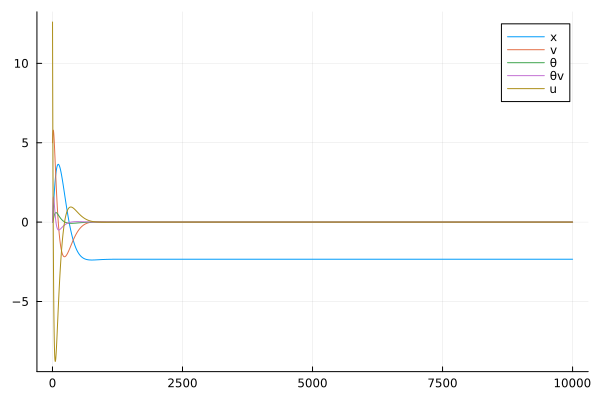

In [896]:
Nl = 10000
x = [zeros(nx) for i = 1:Nl]
x[1] = [0; 5; 0; 0]
u = [zeros(nu) for i = 1:Nl-1]

for k = 1:Nl-1
    u[k] = -cache.Kinf*(x[k] - [5; 0; 0; 0])
    x[k+1] = A*x[k] + B*u[k]
end

plot(hcat(x...)', label=["x" "v" "θ" "θv"])
plot!(hcat(u...)', label="u")

In [898]:
X1 = [SVector{2}([x_[1]; (x_[3] + pi)]) for x_ in x];
# visualize!(vis, model, t_vec, X1)
visualize!(vis, model, Nl*h, X1)

In [877]:
include("TinyMPC.jl")


rg = 0
θg = 0
vg = 0
θ̇g = 0
xg = [rg; vg; θg; θ̇g];

# Create trajectory to follow
Xref = [xg for i = 1:Nl]
Uref = [zeros(nu) for i = 1:Nl-1]

x = [zeros(nx) for i = 1:Nl]
# x[1] = X̃ref[k]
# x[1] = Xref[1]
x[1] .= [0; pi; 0; 0]
u = [zeros(nu) for i = 1:Nl-1]

z = [zeros(nu) for i = 1:Nl-1]
znew = [zeros(nu) for i = 1:Nl-1]
y = [zeros(nu) for i = 1:Nl-1]

q = [zeros(nx) for i = 1:Nl];
r = [zeros(nu) for i = 1:Nl-1];

p = [zeros(nx) for i = 1:Nl];      # cost to go linear term
p[N] = q[N];

d = [zeros(nu) for i = 1:Nl-1];    # feedforward control

params = (
    Q = Q, R = R, Qf = Qf,
    umin = u_min, umax = u_max,
    Xref = Xref, Uref = Uref, 
    # Xref = Xref[k:k+Nh-1], Uref = Uref[k:k+Nh-2], 
    cache = cache
);

# Solve
Δu = 0
Δu, status, iter = solve_admm!(vis, params, q, r, p, d, x, u, z, znew, y; ρ=ρ, abs_tol=1e-2, max_iter=200)

([[5.009326188484049], [5.008380745976643], [5.007475436991283], [5.006563160537117], [4.732615219715308], [4.127603438863048], [3.554971311474625], [3.0131339751362525], [2.5005848189653808], [2.0158915376481876]  …  [-0.0031113594353451663], [-0.0031151008279764014], [-0.003118617237808903], [-0.003121915904200184], [-0.003125004231465384], [-0.003127889801986897], [-0.0031305803900957205], [-0.0031330839767701774], [-0.0031354087652001876], [-0.003137563197268203]], 1, 48)

In [774]:
@show iter
Δu
;

iter = 48


In [775]:
t_vec

0.0:0.01:5.0

In [879]:
X1 = [SVector{2}([x_[1]; (x_[3]+pi)]) for x_ in x];
visualize!(vis, model, Nl*h, X1)

# Nl = 50000
# t_vec_2 = 0.0:h:Nl*h
# xhist = [zeros(4) for i = 1:Nl]
# xhist[1] = [0; pi; 0; 0]
# for k = 1:Nl-1
#     xhist[k+1] = cartpole_rk4(xhist[k], 0)
#     if k % Nl/10 == 0
#         display(xhist[k+1])
#     end
# end
# X1 = [SVector{4}(x_) for x_ in xhist];
# visualize!(vis, model, t_vec_2[Nl], X1)

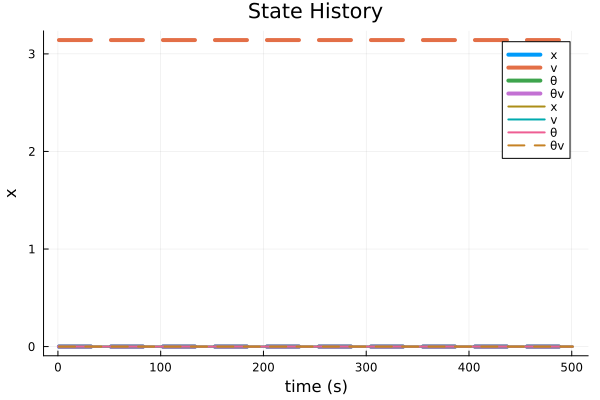

In [261]:
Xsim_m = hcat(x...)
Usim_m = hcat(Δu...)
Xref_m = hcat(Xref...)
plot(Xref_m',label=["x" "v" "θ" "θv"],
linestyle=[:dash :dash :dash], linewidth=[4 4 4])

display(plot!(Xsim_m',label=["x" "v" "θ" "θv"],
linestyle=[:solid :solid :solid :dash :dash :dash :dash], linewidth=[2 2 2 2 2 2 2],
            title="State History", xlabel="time (s)", ylabel="x"))